In [2]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

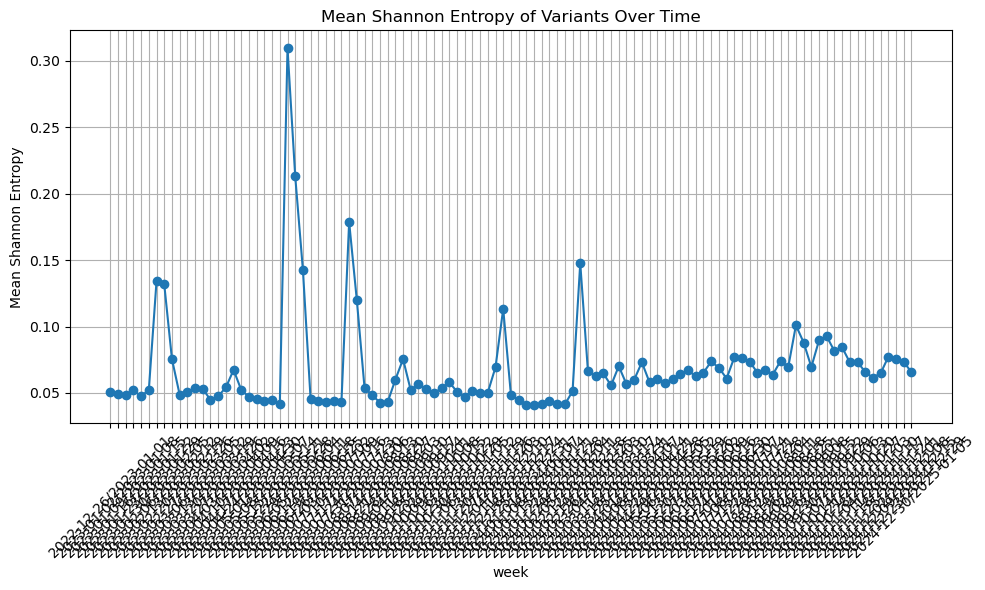

In [3]:
# Calculate Shannon entropy
def shannon_entropy(p):
    if p == 0 or p == 1:
        return 0
    return -(p * np.log(p) + ((1 - p) * np.log(1 - p))) / np.log(2)

df = pd.read_csv('../data/search_metadata.csv')

for file in os.listdir('../data/ivar'):
    sample = file.split('.trimmed')[0]
    if sample in df['sample'].values:
        variants = pd.read_csv(f'../data/ivar/{file}', sep='\t')
        df.loc[df['sample'] == sample, 'entropy'] = variants['ALT_FREQ'].apply(shannon_entropy).mean()


# Bin by week
df['collection_date'] = pd.to_datetime(df['collection_date'])
df['week'] = df['collection_date'].dt.to_period('W')

df = df.sort_values(by='collection_date')
df.set_index('week', inplace=True)
df = df.groupby('week').agg({'entropy': 'mean'}).reset_index()


#plot entropy over time

plt.figure(figsize=(10,6))
plt.plot(df['week'].astype(str), df['entropy'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('week')
plt.ylabel('Mean Shannon Entropy')
plt.title('Mean Shannon Entropy of Variants Over Time')
plt.grid()
plt.tight_layout()
plt.show()


In [4]:
# Viral load data


point_loma = pd.read_csv("qPCR/PointLoma_sewage_qPCR.csv")
encina = pd.read_csv("qPCR/Encina_sewage_qPCR.csv")
south_bay = pd.read_csv("qPCR/SouthBay_sewage_qPCR.csv")

# join on date
viral_load = point_loma.merge(encina, on="Sample_Date", suffixes=("_point_loma", "_encina"))
viral_load = viral_load.merge(south_bay, on="Sample_Date")

viral_load = viral_load.merge(south_bay, on="Sample_Date", suffixes=("", "_south_bay"))

viral_load["Sample_Date"] = pd.to_datetime(viral_load["Sample_Date"])
viral_load = viral_load.sort_values("Sample_Date")

viral_load = viral_load[viral_load["Sample_Date"] >= "2023-01-01"]
viral_load = viral_load[viral_load["Sample_Date"] <= "2024-12-31"]

# plot average viral load across the three locations
viral_load["Total_average_viral_load"] = viral_load[["Mean viral gene copies/L_point_loma", "Mean viral gene copies/L_encina", "Mean viral gene copies/L_south_bay"]].mean(axis=1)

print(viral_load.head())

viral_load['week'] = viral_load['Sample_Date'].dt.to_period('W')

viral_load = viral_load.groupby('week').agg({'Total_average_viral_load': 'mean'}).reset_index()

print(viral_load.head())

df = df.merge(viral_load, on="week", how="left")

# # plot total average viral load over time
# plt.figure(figsize=(10,6))
# plt.plot(viral_load['month'], viral_load['Total_average_viral_load'], marker='o', color='orange')
# plt.xticks(rotation=45)
# plt.xlabel('Date')
# plt.ylabel('Average Viral Load (gene copies/L)')
# plt.title('Average Viral Load in Sewage Over Time')
# plt.grid()
# plt.tight_layout()
# plt.show()

# df.head()

   Sample_Date  Mean viral gene copies/L_point_loma  \
23  2023-01-17                              1192785   
24  2023-02-14                              7378099   
25  2023-02-19                              2222741   
26  2023-02-21                              1426471   
27  2023-02-28                              1152097   

    Mean viral gene copies/L_encina  Mean viral gene copies/L  \
23                           596658                    342787   
24                          1296872                    872514   
25                          1413569                    210707   
26                           941072                    113193   
27                           608824                    107977   

    Mean viral gene copies/L_south_bay  Total_average_viral_load  
23                              342787              7.107433e+05  
24                              872514              3.182495e+06  
25                              210707              1.282339e+06  
26        

/tmp/ipykernel_930291/1130511338.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  viral_load["Sample_Date"] = pd.to_datetime(viral_load["Sample_Date"])


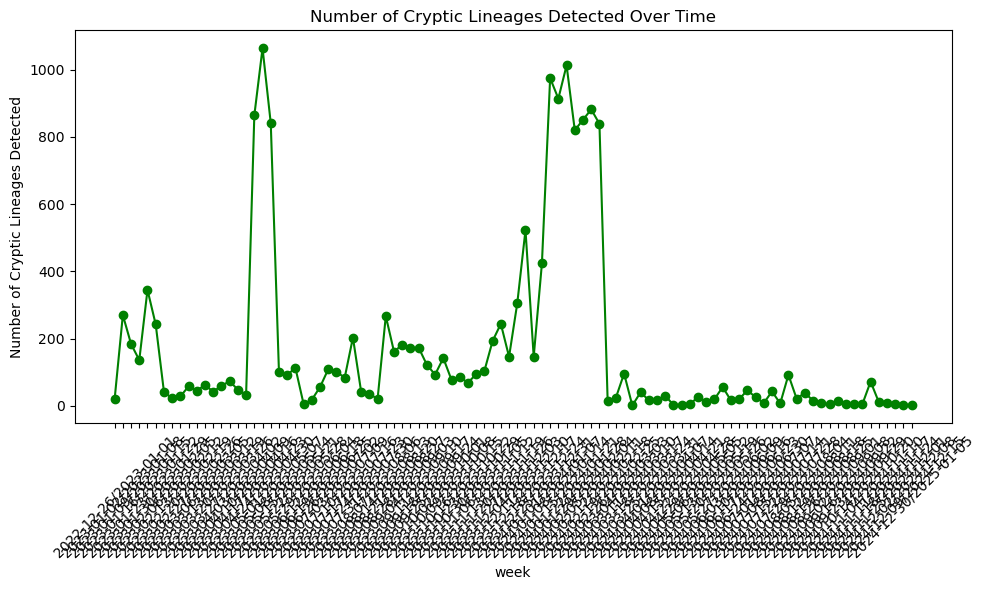

In [5]:
cryptic_detects = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')

cryptic_detects['collection_date'] = pd.to_datetime(cryptic_detects['collection_date'])
cryptic_detects['week'] = cryptic_detects['collection_date'].dt.to_period('W')
cryptic_detects['num_snps'] = cryptic_detects['nt_mutations'].apply(lambda x:len(x.split(' ')))
cryptic_detects = cryptic_detects[cryptic_detects['num_snps'] > 1]
df_cryptic = cryptic_detects[cryptic_detects['num_clinical_detections'] == 0]


df_cryptic = df_cryptic.groupby(df_cryptic['week']).agg({'collection_date': 'count'}).rename(
    columns={'collection_date': 'cryptic_count'}).reset_index()

df_cryptic.set_index('week', inplace=True)

df = df.join(df_cryptic, on='week', how='left')

# plot cryptic counts over time
plt.figure(figsize=(10,6))
plt.plot(df_cryptic.index.astype(str), df_cryptic['cryptic_count'], marker='o', color='green')
plt.xticks(rotation=45)
plt.xlabel('week')
plt.ylabel('Number of Cryptic Lineages Detected')
plt.title('Number of Cryptic Lineages Detected Over Time')
plt.tight_layout()
plt.show()

In [6]:
# Median coverage

# median_coverage = pd.read_csv("median_coverage_summary.tsv", sep='\t')
# median_coverage['sample'] = median_coverage['sample'].str.split('.trimmed').str[0]
# metadata = pd.read_csv('../data/search_metadata.csv')
# metadata = metadata[['sample', 'collection_date']]
# median_coverage = median_coverage.merge(metadata, on='sample', how='left')

# median_coverage['collection_date'] = pd.to_datetime(median_coverage['collection_date'])
# median_coverage['month'] = median_coverage['collection_date'].dt.to_period('M')
# median_coverage = median_coverage.groupby('month').agg({'MedianCoverage': 'mean'}).reset_index()
# df = df.merge(median_coverage, on="month", how="left")

Mean Squared Error: 45867.802218278564
R^2 Score: 0.0884333341327529
Coefficients: [-84.90112251  40.38150028]


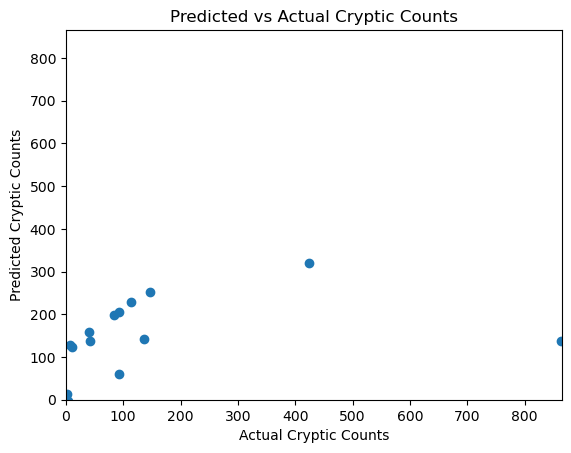

,week,entropy,Total_average_viral_load,cryptic_count
3,2023-01-16/2023-01-22,0.051982,7.107433e+05,136.0
7,2023-02-13/2023-02-19,0.131696,2.232417e+06,22.0
8,2023-02-20/2023-02-26,0.075435,8.269120e+05,28.0
9,2023-02-27/2023-03-05,0.048672,6.229660e+05,58.0
10,2023-03-06/2023-03-12,0.050900,1.644218e+06,45.0
...,...,...,...,...
98,2024-11-11/2024-11-17,0.065774,2.137714e+06,72.0
99,2024-11-18/2024-11-24,0.061493,2.614819e+06,11.0
100,2024-11-25/2024-12-01,0.064867,3.786990e+06,7.0
101,2024-12-02/2024-12-08,0.077295,2.400786e+06,5.0


In [7]:
# Fit linear model to predict cryptic counts from entropy and total_average_viral_load

df = df.dropna(subset=['cryptic_count', 'Total_average_viral_load'])
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

train, test = train_test_split(df, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(train[['entropy', 'Total_average_viral_load']])
X_test = scaler.fit_transform(test[['entropy', 'Total_average_viral_load']])

y_train = train['cryptic_count']#.fillna(0)
y_test = test['cryptic_count']#.fillna(0)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
print(f'Coefficients: {model.coef_}')

# match x and y limits
max_val = max(max(y_test), max(y_pred))
plt.xlim(0, max_val + 1)
plt.ylim(0, max_val + 1)

# plot predicted vs actual
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Cryptic Counts')
plt.ylabel('Predicted Cryptic Counts')
plt.title('Predicted vs Actual Cryptic Counts')
#plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--')
plt.show()

df
